# Codecademy Final Project 1: Video Game Sale Data

In this 2 part project, I want to analyze various aspects of video game sale data.

#### 1. How have global video game sales shifted across regions (NA, EU, JP, Other) over time?

    Reason: Reveals market expansion/contraction and shifting consumer bases (e.g., rise of Asia, decline of Japan’s relative share).

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

game_data = 'Video_Games.csv'
df = pd.read_csv(game_data)

# Quick exploration
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nYear range: {min(df['Year_of_Release'])} - {max(df['Year_of_Release'])}")

# Check missing values in sales columns
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
missing_summary = df[sales_cols].isnull().sum()
print(f"\nMissing values per sales column:\n{missing_summary}")

#see shape of original data
df

Dataset shape: (16719, 16)

Column names: ['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating']

Year range: 1980.0 - 2020.0

Missing values per sales column:
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,LMA Manager 2007,X360,2006.0,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016.0,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


# 1. How have global video game sales shifted across regions (NA, EU, JP, Other) over time?

    Reason: Reveals market expansion/contraction and shifting consumer bases (e.g., rise of Asia, decline of Japan’s relative share).

### VISUALIZATION 1: Time Series Line Plot. A simple comparison of all regions over time.


In [129]:
# Define region mapping and column mapping
region_mapping = {
    'NA_Sales': 'North America',
    'EU_Sales': 'Europe', 
    'JP_Sales': 'Japan',
    'Other_Sales': 'Other'
}

# Perform melt operation (NO apply wrapper)
df_melted_temp = df.melt(
    id_vars=['Year_of_Release'],
    value_vars=list(region_mapping.keys()),  # Only the numeric sales columns
    var_name='Region_Column',                 # This will hold original column names like 'NA_Sales'
    value_name='Sales_Millions'               # This will hold the sales values
)
# Convert region column to full readable names
df_melted_temp['Region'] = df_melted_temp['Region_Column'].map(region_mapping)

# Drop the temporary column that holds original names
df_melted_temp = df_melted_temp.drop(columns=['Region_Column'])

# Result structure will be: [Year_of_Release, Region, Sales_Millions]
print(f"\nMelted dataset shape: {df_melted_temp.shape}")
print(f"Columns:\n{df_melted_temp.columns}\n")
print(f"Unique regions: {sorted(df_melted_temp['Region'].unique())}\n")
print(f"First 5 rows:\n{df_melted_temp.head()}")


Melted dataset shape: (66876, 3)
Columns:
Index(['Year_of_Release', 'Sales_Millions', 'Region'], dtype='str')

Unique regions: ['Europe', 'Japan', 'North America', 'Other']

First 5 rows:
   Year_of_Release  Sales_Millions         Region
0           2006.0           41.36  North America
1           1985.0           29.08  North America
2           2008.0           15.68  North America
3           2009.0           15.61  North America
4           1996.0           11.27  North America


### Visualization 1: Regional Sales Volume Comparison, side by side.

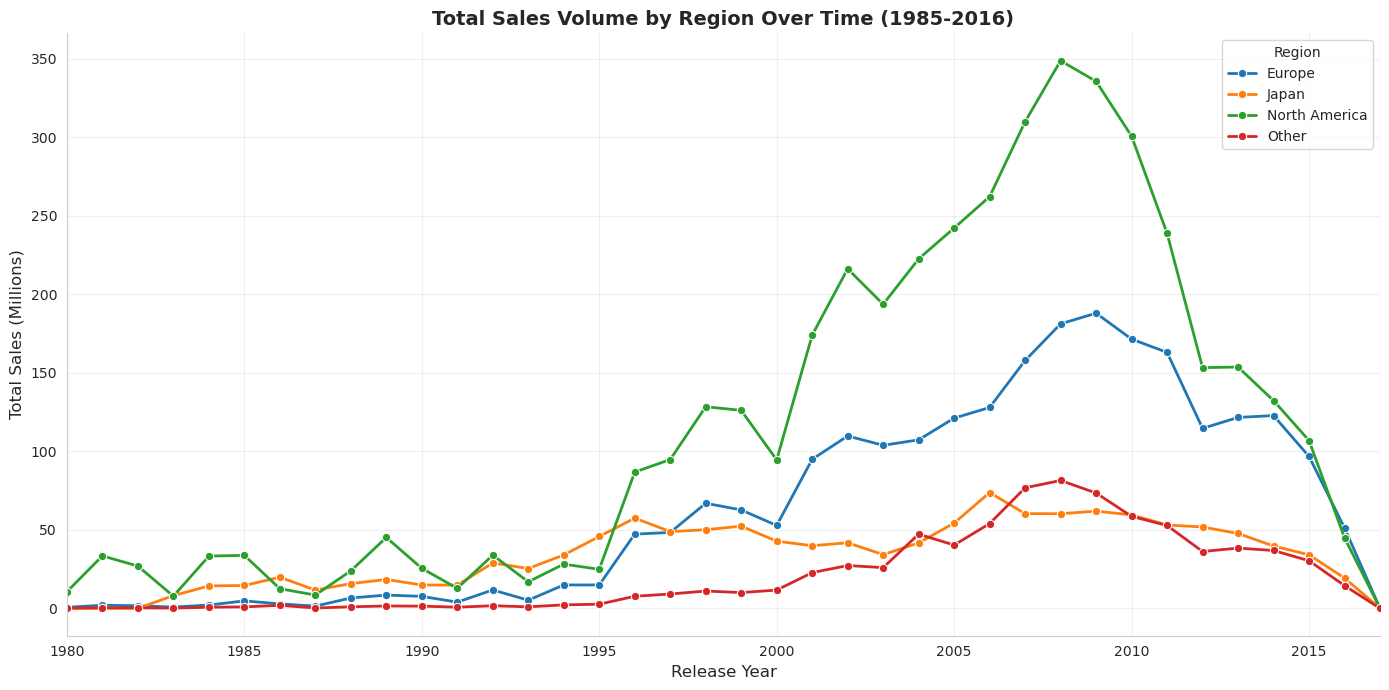

In [130]:
# Group by Year AND Region, then sum sales
region_over_time = valid_data.groupby(['Year_of_Release', 'Region'])['Sales_Millions'].sum().reset_index()

# Plot
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=region_over_time, 
    x='Year_of_Release', 
    y='Sales_Millions', 
    hue='Region',
    marker='o',
    linewidth=2
)

plt.title('Total Sales Volume by Region Over Time (1985-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.xlim(left=1980, right=2017)
plt.ylabel('Total Sales (Millions)', fontsize=12)
plt.legend(title='Region')
plt.grid(True, alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

#### Analysis:
We see here that North America vastly outperforms all other countries in sales for the duration of the whole of the dataset. we also see a massive spike of sales around 2000 to 2013.

#### Viz 2: Modify total into averages per region per year.

   Year_of_Release         Region  Sales_Millions
0           1980.0         Europe        0.074444
1           1980.0          Japan        0.000000
2           1980.0  North America        1.176667
3           1980.0          Other        0.013333
4           1981.0         Europe        0.042609
5           1981.0          Japan        0.000000
6           1981.0  North America        0.726087
7           1981.0          Other        0.006957
8           1982.0         Europe        0.045833
9           1982.0          Japan        0.000000


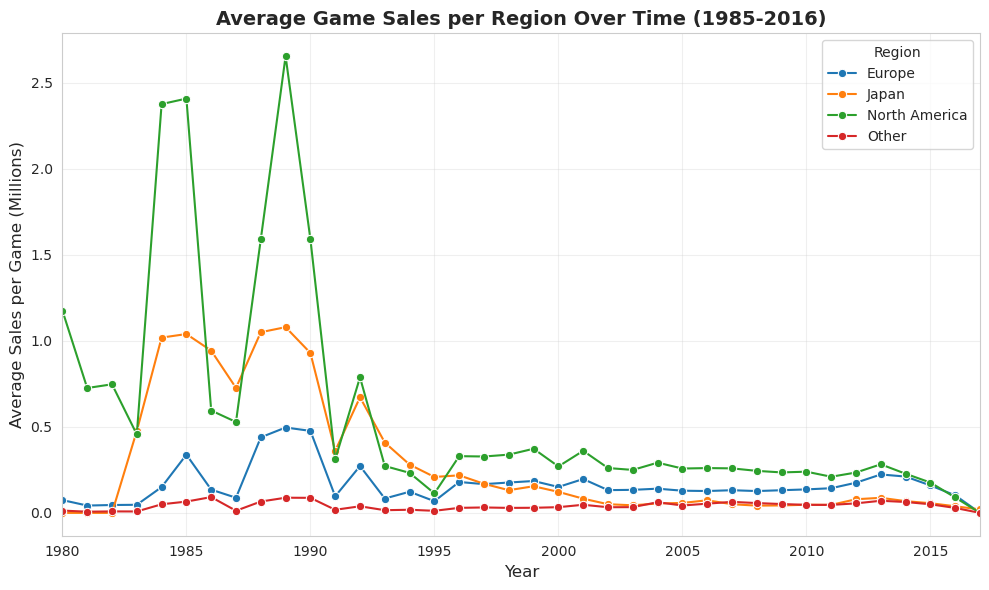

In [131]:
avg_by_year = valid_data.groupby(['Year_of_Release','Region'])['Sales_Millions'].mean().reset_index()
print(avg_by_year.head(10))
plt.figure(figsize=(10,6))

sns.lineplot(
    data = avg_by_year,
    x = 'Year_of_Release',
    y = 'Sales_Millions',
    hue = 'Region',
    marker = 'o'
)
plt.title('Average Game Sales per Region Over Time (1985-2016)', fontsize=14, fontweight='bold')
plt.xlim(left=1980, right=2017)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Sales per Game (Millions)', fontsize=12)
plt.legend(title='Region')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Here, we can observe two things: We see two massive spikes around 1984 - 1986, and another 1989. North America has the hugest spikes, while other regions like Japan and Europe experienced similar, albeit less extreme spikes. There's also one more spike around 1992-1993.

#### POINT OF INTEREST: *Why did average game sales spike around the 80s & early 90s, but the total game sales increased massively after 1995, despite not showing up in the averages?*



### Viz 3: Number of individual Games Sold per year

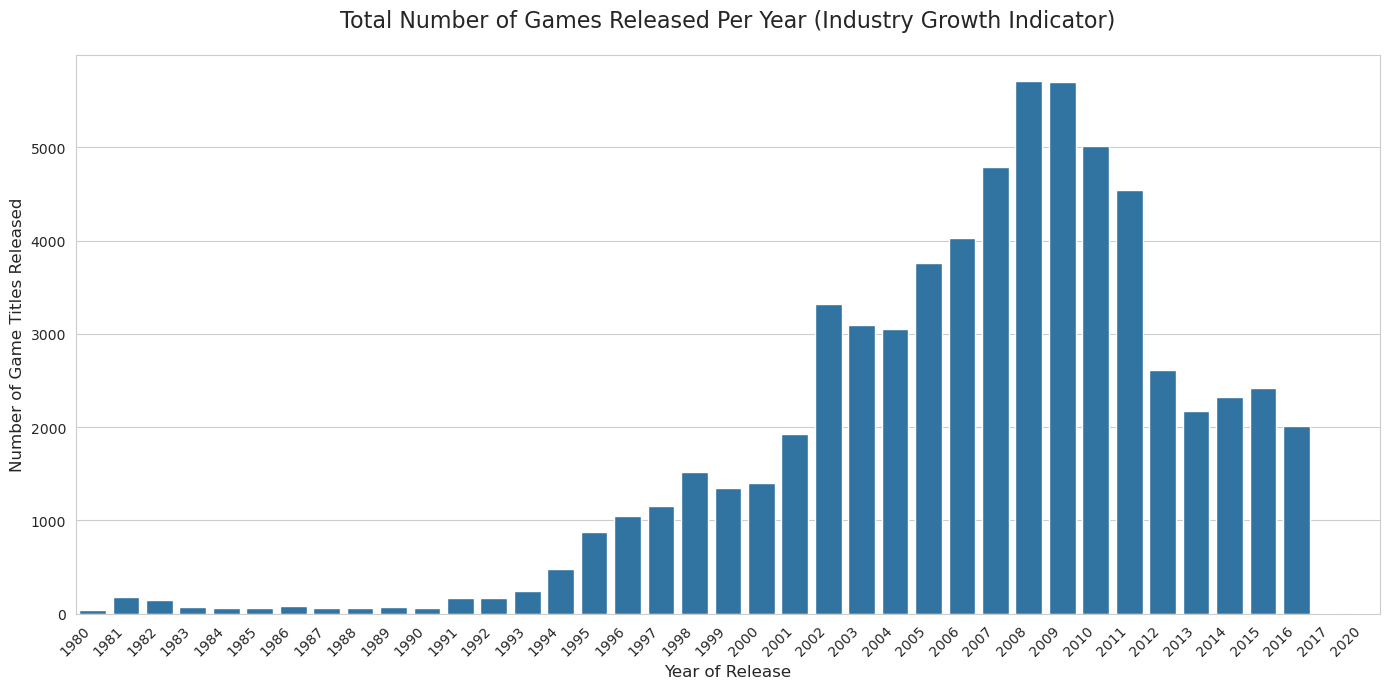

In [132]:
game_counts = df_melted_temp.groupby(['Year_of_Release']).size().reset_index(name='Game_Count')

game_counts['Year_of_Release'] = game_counts['Year_of_Release'].astype(int)

sns.set_style("whitegrid")
plt.figure(figsize=(14,7))
sns.barplot(
    data = game_counts,
    x='Year_of_Release',
    y='Game_Count'
)
plt.title('Total Number of Games Released Per Year (Industry Growth Indicator)', fontsize=16, pad=20)
plt.xlabel('Year of Release', fontsize=12)
plt.ylabel('Number of Game Titles Released', fontsize=12)


# Rotate x-axis labels for better viewing
plt.xticks(rotation=45, ha='right') 


plt.tight_layout() # Adjusts plot to fit all elements cleanly
plt.show()

### INSIGHT: THE REASON FOR AVERAGE VS TOTAL SALES DISCREPANCY:

Here, we can see that the total number of game titles released expanded dramatically from the 80s to the early 2000s onwards. Averages dipped after the 80s and 90s since there were just a greater number of games being releaed after the 2000s. That means that games sold less individually on average due to the sheer market saturation

### Viz 4: Regional Market Share Over Time 

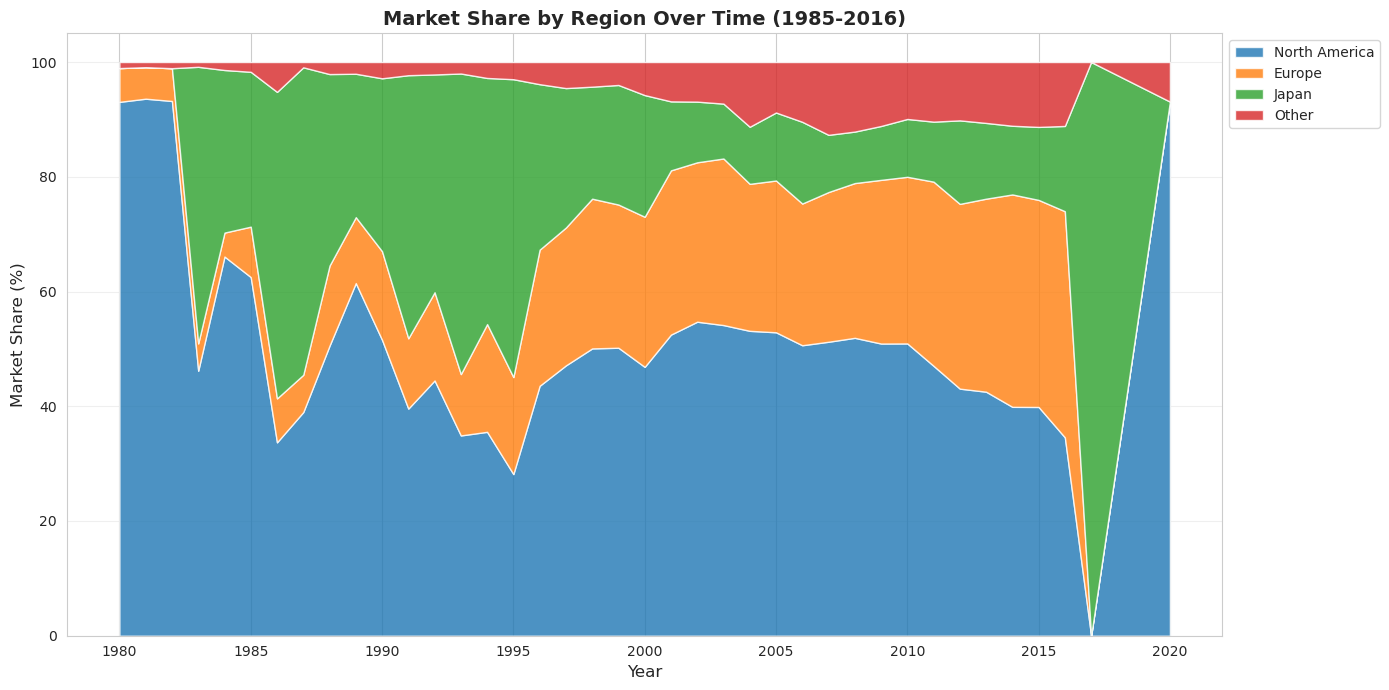

In [133]:
# Group by Year and Region to get total sales per region per year
region_year = valid_data.groupby(['Year_of_Release', 'Region'])['Sales_Millions'].sum().reset_index()

# Calculate total sales per year (all regions combined)
year_total = region_year.groupby('Year_of_Release')['Sales_Millions'].sum().reset_index()
year_total.rename(columns={'Sales_Millions': 'Year_Total'}, inplace=True)

# Merge and compute percentage share
region_year = region_year.merge(year_total, on='Year_of_Release')
region_year['Share_Percent'] = (region_year['Sales_Millions'] / region_year['Year_Total']) * 100

# Pivot for plotting (years as rows, regions as columns)
pivot_share = region_year.pivot(index='Year_of_Release', columns='Region', values='Share_Percent').fillna(0)

# Create stacked area plot
plt.figure(figsize=(14, 7))
regions = ['North America', 'Europe', 'Japan', 'Other']  # adjust names as they appear in your data

# Extract data for each region (if they exist)
stack_data = [pivot_share[r] for r in regions if r in pivot_share.columns]
plt.stackplot(pivot_share.index, *stack_data, labels=regions, alpha=0.8)

plt.title('Market Share by Region Over Time (1985-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Market Share (%)', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

#### Analysis:

We can clearly see here that for the 80s - mid-90s, the market is mostly dominated by North America and Japan. Starting from 1995 onwards, we can see that Japan begins to loose steam in terms of market share, and Europe takes its place in dominance. This can possibly be contributed to the Heisei Recession era following the rippling effects of the Japanese Real Estate market collapsing. I assume that It probably has something to do with the economic downturn causing game studios to downsize in the region.

#### Viz 5: Quick summary stats table
- simple key stats at a glance

In [134]:
# Viz 5: Quick summary stats using the melted dataframe from previous cells
print("Global Sales Statistics:")
print("-" * 40)

for region in df_melted_temp['Region'].unique():
    region_data = df_melted_temp[df_melted_temp['Region'] == region]
    print(f"{region}:")
    total_sales = region_data['Sales_Millions'].dropna().sum()
    peak_year_region = region_data.loc[region_data['Sales_Millions'].idxmax(), 'Year_of_Release'] if not region_data['Sales_Millions'].isna().all() else None
    print(f"  Total: ${total_sales:.1f}M")
    if peak_year_region is not None:
        print(f"  Peak Year: {peak_year_region:.0f}")

print("\n" + "-" * 40)

Global Sales Statistics:
----------------------------------------
North America:
  Total: $4402.6M
  Peak Year: 2006
Europe:
  Total: $2424.7M
  Peak Year: 2006
Japan:
  Total: $1297.4M
  Peak Year: 1996
Other:
  Total: $791.3M
  Peak Year: 2004

----------------------------------------


# 2. Which genres consistently outperform others in each major region (NA, EU, JP)?

    Reason: A publisher could tailor its portfolio regionally (e.g., RPGs for Japan, shooters/sports for NA/EU)

In [135]:
# Data Preparation and Cleaning
# Drop rows where key regional sales columns are NaN for accurate analysis.
print(f"Initial DataFrame size: {df.shape}")
df_cleaned = df.dropna(subset=['NA_Sales', 'EU_Sales', 'JP_Sales']).copy()
print(f"Cleaned DataFrame size after dropping NaNs: {df_cleaned.shape}")

# Aggregation - Calculate total sales per genre across all regions
genre_sales = df_cleaned.groupby('Genre').agg({
    'NA_Sales': 'sum',
    'EU_Sales': 'sum',
    'JP_Sales': 'sum'
}).reset_index()

genre_sales['Total_Global_Sales'] = genre_sales['NA_Sales'] + genre_sales['EU_Sales'] + genre_sales['JP_Sales']

print("\nAggregated Genre Sales Data:")
print(genre_sales)

# Comparative Analysis and Visualization
# 1. Identify the top genres for each region (optional, but useful for comparison)
top1_na = genre_sales.sort_values('NA_Sales', ascending=False).iloc[0]['Genre']
top1_eu = genre_sales.sort_values('EU_Sales', ascending=False).iloc[0]['Genre']
top1_jp = genre_sales.sort_values('JP_Sales', ascending=False).iloc[0]['Genre']

print(f"\nTop Genre by NA Sales: {top1_na}")
print(f"Top Genre by EU Sales: {top1_eu}")
print(f"Top Genre by JP Sales: {top1_jp}")

Initial DataFrame size: (16719, 16)


Cleaned DataFrame size after dropping NaNs: (16719, 16)

Aggregated Genre Sales Data:
           Genre  NA_Sales  EU_Sales  JP_Sales  Total_Global_Sales
0         Action    879.01    519.13    161.44             1559.58
1      Adventure    105.26     63.54     52.30              221.10
2       Fighting    223.36    100.33     87.48              411.17
3           Misc    407.27    212.74    108.11              728.12
4       Platform    445.50    200.35    130.83              776.68
5         Puzzle    122.87     50.01     57.31              230.19
6         Racing    359.35    236.51     56.71              652.57
7   Role-Playing    330.81    188.71    355.46              874.98
8        Shooter    592.24    317.34     38.76              948.34
9     Simulation    182.19    113.52     63.80              359.51
10        Sports    684.43    376.79    135.54             1196.76
11      Strategy     68.55     45.17     49.66              163.38

Top Genre by NA Sales: Action
Top Genre by

          Genre  Total_Global_Sales
0        Action             1559.58
1      Platform              776.68
2  Role-Playing              874.98
3       Shooter              948.34
4        Sports             1196.76


/tmp/ipykernel_803/2971830013.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Genre', y='Total_Global_Sales', data=plot_data_agg, ci=None)


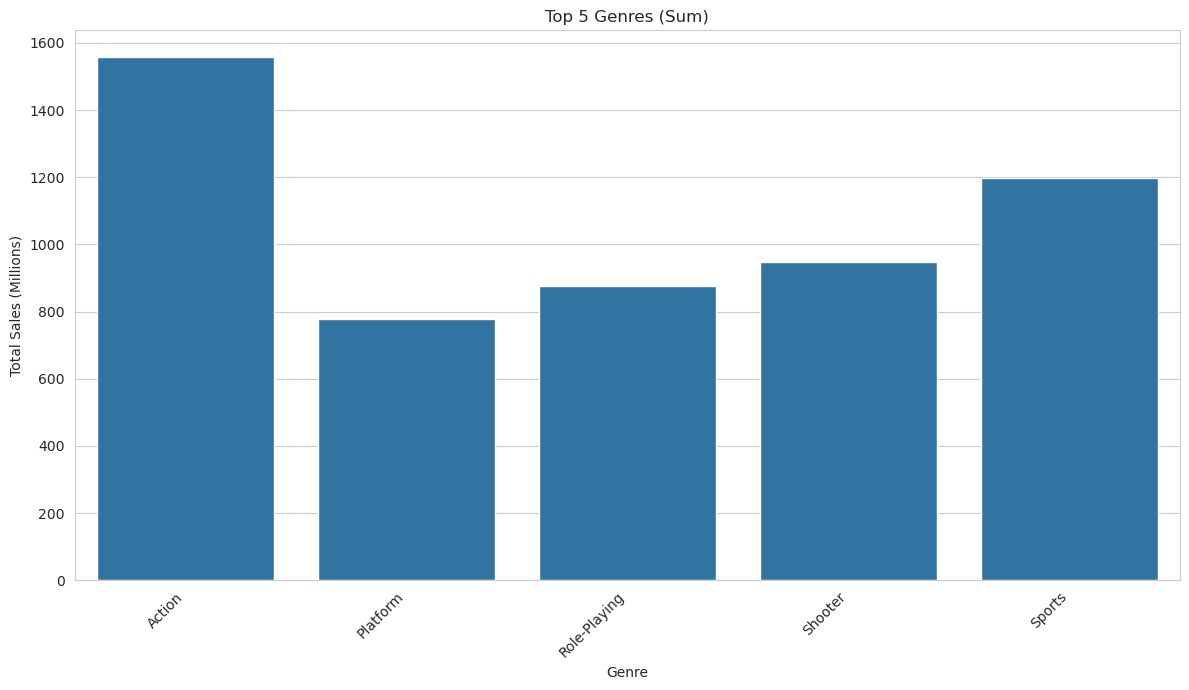

/tmp/ipykernel_803/2971830013.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=na_sorted, x='NA_Sales', y='Genre', ax=axes[0], palette='Blues_r')
/tmp/ipykernel_803/2971830013.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=eu_sorted, x='EU_Sales', y='Genre', ax=axes[1], palette='Greens_r')
/tmp/ipykernel_803/2971830013.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=jp_sorted, x='JP_Sales', y='Genre', ax=axes[2], palette='Reds_r')


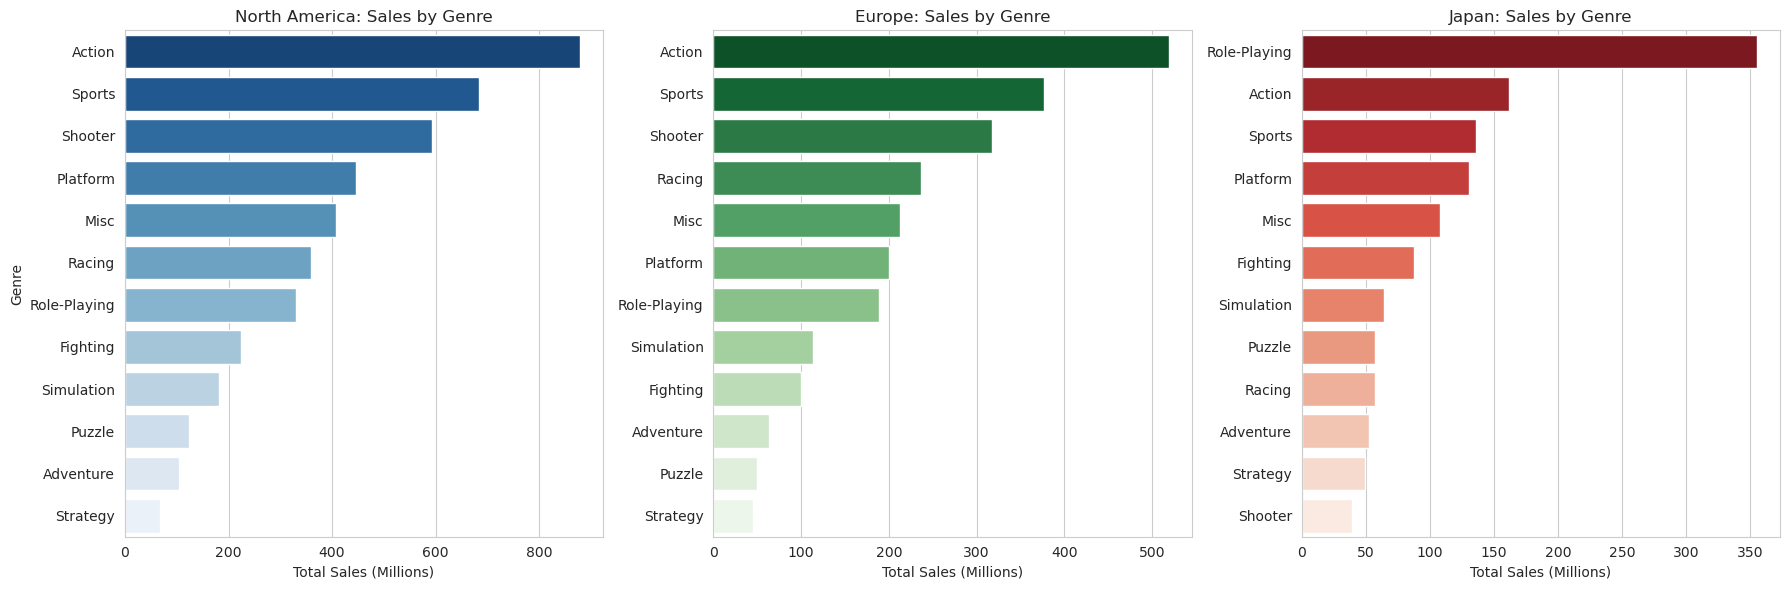

In [137]:
# 2. Visualization: Create a grouped bar chart for the top N genres (e.g., top 5)
# Select the Top 5 genres based on total global sales for visualization clarity
top_genres_visual = genre_sales.sort_values('Total_Global_Sales', ascending=False).head(5)['Genre'].tolist()

# Use .agg() to aggregate Total_Sales into a single sum column for plotting convenience
plot_data = genre_sales[genre_sales['Genre'].isin(top_genres_visual)]
plot_data_agg = plot_data.groupby(['Genre']).agg({'Total_Global_Sales': 'sum'}).reset_index()

print(plot_data_agg)

plt.figure(figsize=(12, 7))
sns.barplot(x='Genre', y='Total_Global_Sales', data=plot_data_agg, ci=None)
plt.title('Top 5 Genres (Sum)')
plt.xlabel('Genre')
plt.ylabel('Total Sales (Millions)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2.a VISUALIZATION: create 3 separate bar charts for the same top genres split by the 3 main reagions

# Create separate dataframes for each region, sorted descending
na_sorted = genre_sales[['Genre', 'NA_Sales']].sort_values('NA_Sales', ascending=False)
eu_sorted = genre_sales[['Genre', 'EU_Sales']].sort_values('EU_Sales', ascending=False)
jp_sorted = genre_sales[['Genre', 'JP_Sales']].sort_values('JP_Sales', ascending=False)

# Set up subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot North America
sns.barplot(data=na_sorted, x='NA_Sales', y='Genre', ax=axes[0], palette='Blues_r')
axes[0].set_title('North America: Sales by Genre', fontsize=12)
axes[0].set_xlabel('Total Sales (Millions)')
axes[0].set_ylabel('Genre')

# Plot Europe
sns.barplot(data=eu_sorted, x='EU_Sales', y='Genre', ax=axes[1], palette='Greens_r')
axes[1].set_title('Europe: Sales by Genre', fontsize=12)
axes[1].set_xlabel('Total Sales (Millions)')
axes[1].set_ylabel('')

# Plot Japan
sns.barplot(data=jp_sorted, x='JP_Sales', y='Genre', ax=axes[2], palette='Reds_r')
axes[2].set_title('Japan: Sales by Genre', fontsize=12)
axes[2].set_xlabel('Total Sales (Millions)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

#### Analysis:
With sales metrics per each genre, we can see the sheer size of the North American market, which makes things slightly harder to interpret. Nevertheless, we can see that Action dominates the NA and EU scene, whereas Japan is dominated by Role Playing Games. Makes sense, given how Japan was so innovative in this genre.

#### ISSUE:
Since NA Sales are so large, we need more normalized metrics to more accurately determine how different genres fare in different regions. let's use Regional Contribution Indicies and Cross Regional Ratios. 

REGIONAL CONTRIBUTION INDICIES = Sales of Region / sum of all sales per all regions x 100
CROSS REGIONAL RATIO = calculate the ratios for each genre. example: NA_Sales / EU_Sales, NA / JP, EU / JP, etc...

These more durable indicies help us to determine if a genre's success is highly dependent on a region's sale figure for that genre.


--- Aggregated & Proportional Metrics Head ---
           Genre  Total_Global_Sales     RCI_NA     RCI_EU     RCI_JP
0         Action             1559.58  56.361969  33.286526  10.351505
1      Adventure              221.10  47.607417  28.738128  23.654455
2       Fighting              411.17  54.323029  24.401099  21.275871
3           Misc              728.12  55.934461  29.217711  14.847827
4       Platform              776.68  57.359530  25.795694  16.844775
5         Puzzle              230.19  53.377645  21.725531  24.896824
6         Racing              652.57  55.066889  36.242855   8.690255
7   Role-Playing              874.98  37.807721  21.567350  40.624929
8        Shooter              948.34  62.450176  33.462682   4.087142
9     Simulation              359.51  50.677311  31.576312  17.746377
10        Sports             1196.76  57.190247  31.484174  11.325579
11      Strategy              163.38  41.957400  27.647203  30.395397
           Genre  NA_Sales  EU_Sales  JP_S

<Figure size 1200x700 with 0 Axes>

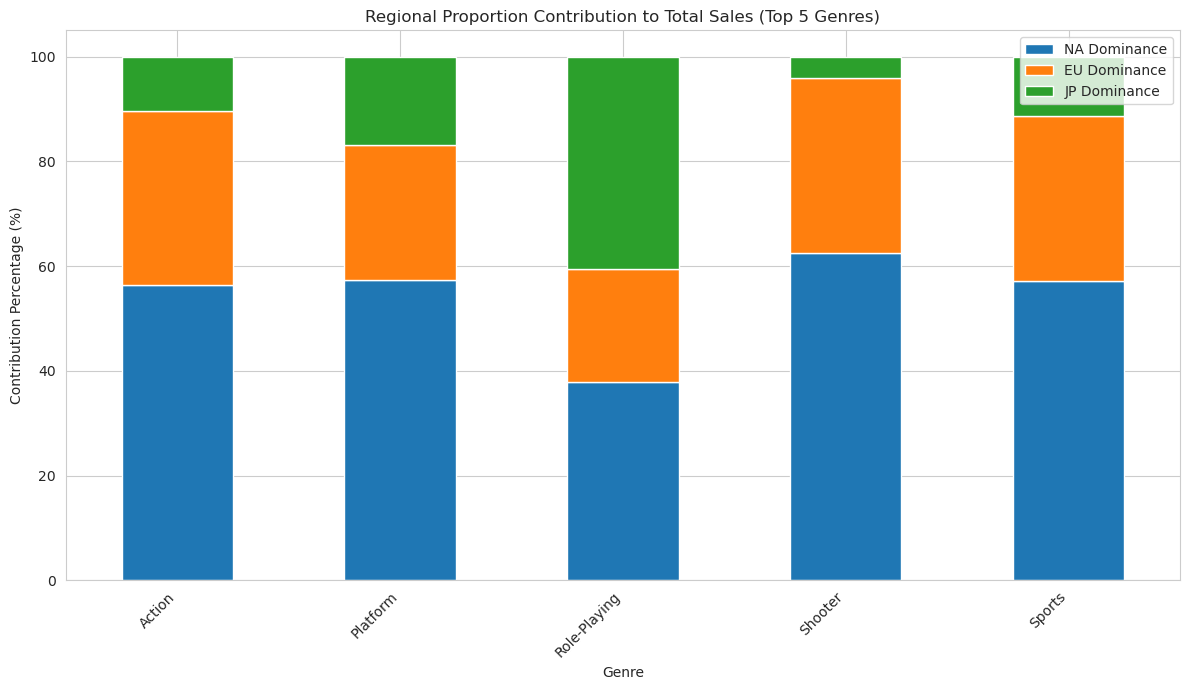

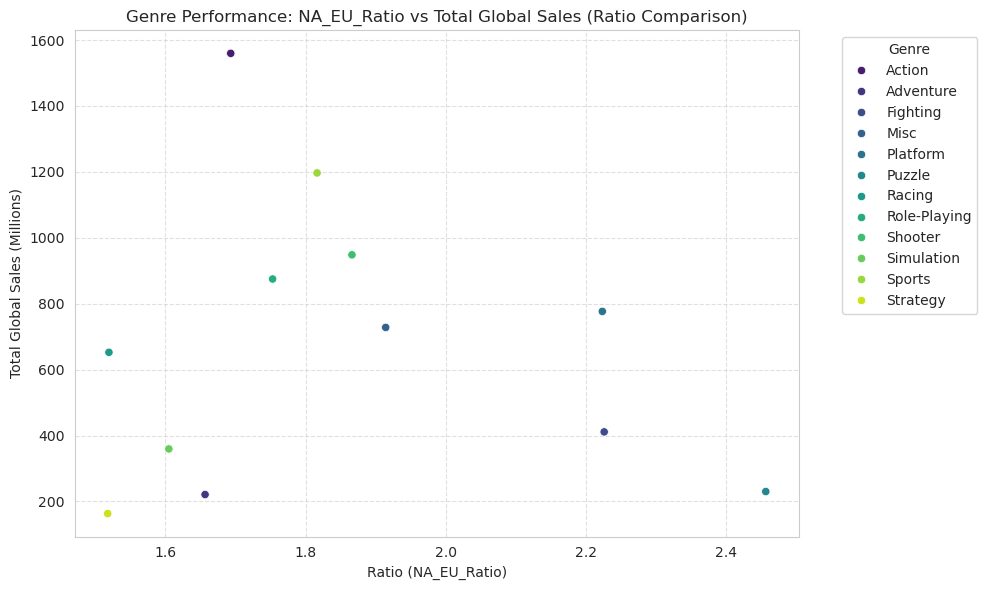

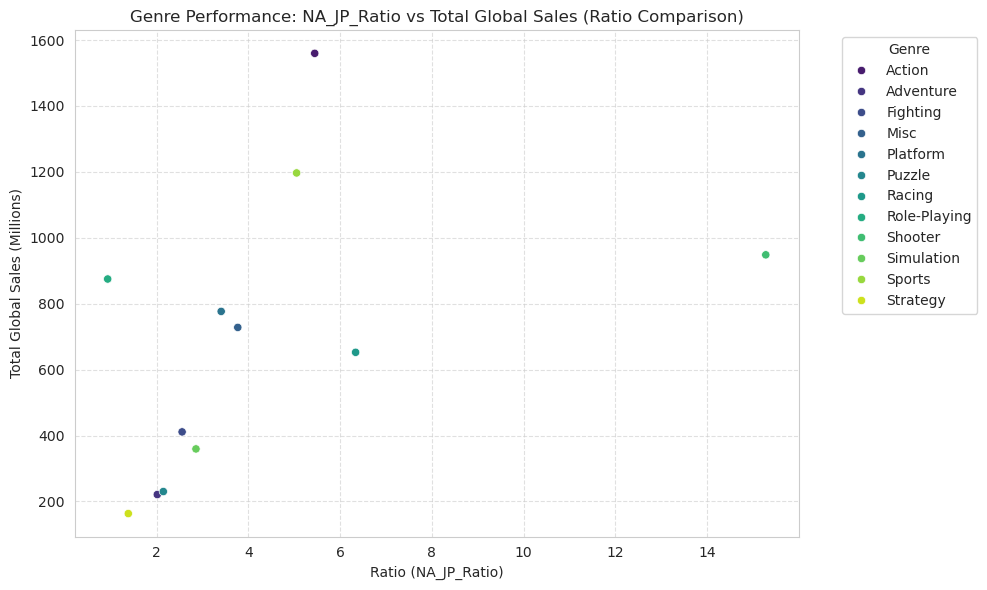

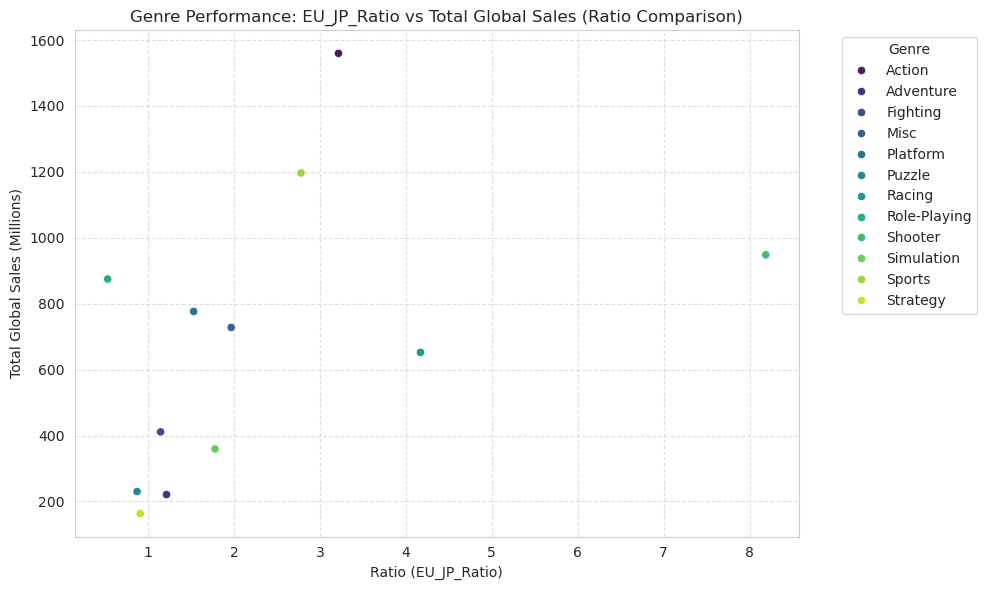

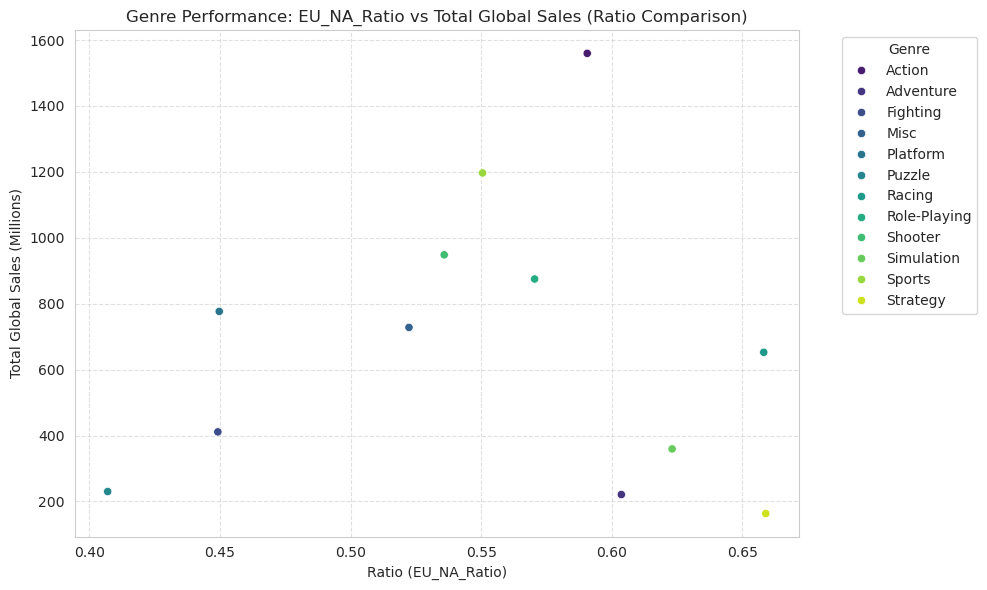

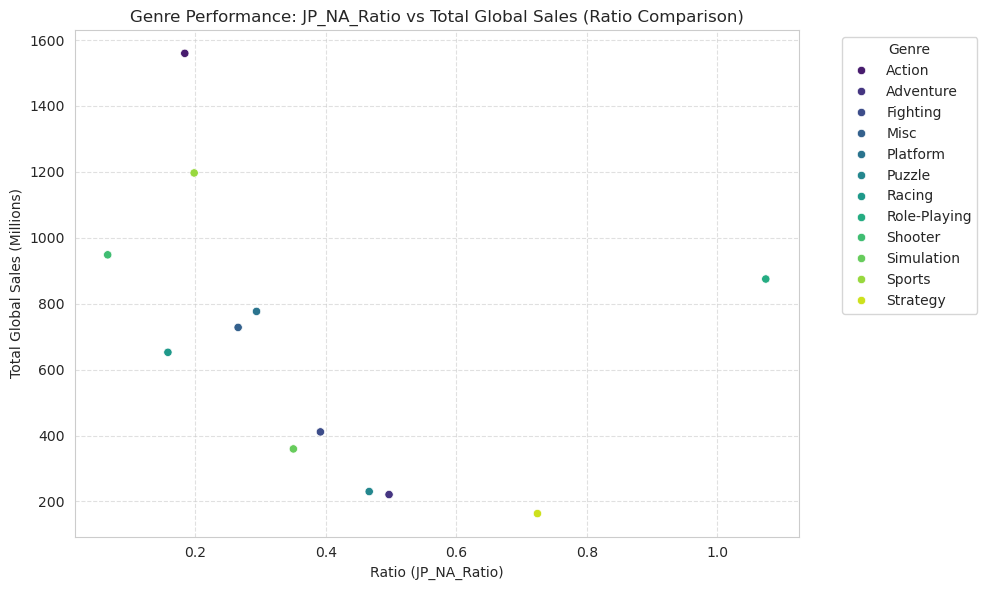

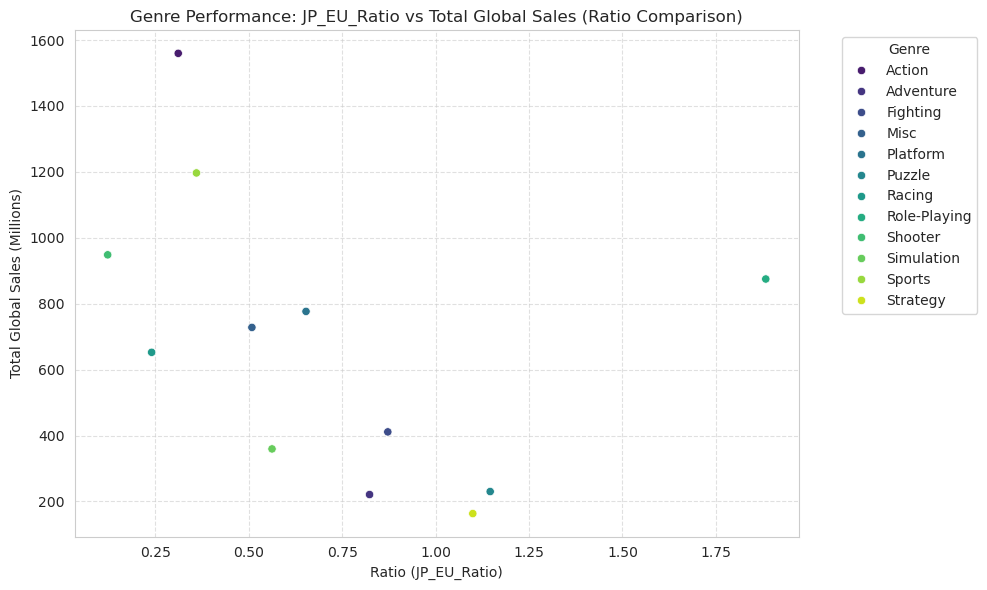

In [143]:
# 1. Regional Contribution Index (RCI): Percentage contribution of each region to the genre's total sales.
genre_sales['RCI_NA'] = (genre_sales['NA_Sales'] / genre_sales['Total_Global_Sales']) * 100
genre_sales['RCI_EU'] = (genre_sales['EU_Sales'] / genre_sales['Total_Global_Sales']) * 100
genre_sales['RCI_JP'] = (genre_sales['JP_Sales'] / genre_sales['Total_Global_Sales']) * 100

# 2. Cross-Regional Ratio (CRR): Comparing the strength relationship between markets.
# Use np.where to prevent division by zero errors, defaulting the ratio to NaN or a safe number (e.g., 1 if both are 0)
genre_sales['NA_EU_Ratio'] = genre_sales['NA_Sales'] / genre_sales['EU_Sales'].replace(0, np.nan)
genre_sales['NA_JP_Ratio'] = genre_sales['NA_Sales'] / genre_sales['JP_Sales'].replace(0, np.nan)
genre_sales['EU_NA_Ratio'] = genre_sales['EU_Sales'] / genre_sales['NA_Sales'].replace(0, np.nan)
genre_sales['EU_JP_Ratio'] = genre_sales['EU_Sales'] / genre_sales['JP_Sales'].replace(0, np.nan)
genre_sales['JP_NA_Ratio'] = genre_sales['JP_Sales'] / genre_sales['NA_Sales'].replace(0, np.nan)
genre_sales['JP_EU_Ratio'] = genre_sales['JP_Sales'] / genre_sales['EU_Sales'].replace(0, np.nan)

print("\n--- Aggregated & Proportional Metrics Head ---")
# Display key proportional columns to confirm calculation
print(genre_sales[['Genre', 'Total_Global_Sales', 'RCI_NA', 'RCI_EU', 'RCI_JP']])

TOP_N = 5
top_genres_visual = genre_sales.sort_values('Total_Global_Sales', ascending=False).head(TOP_N)['Genre'].tolist()

# Filter data to only include these top N genres
plot_data = genre_sales[genre_sales['Genre'].isin(top_genres_visual)]
print(plot_data)

# 1. Stacked Bar Chart for RCI visualization (Proportional contribution)
rci_data = plot_data[['Genre', 'RCI_NA', 'RCI_EU', 'RCI_JP']]

plt.figure(figsize=(12, 7))
# Using pandas plotting method which is good for stacked proportional charts
rci_data.set_index('Genre')[['RCI_NA', 'RCI_EU', 'RCI_JP']].plot(kind='bar', stacked=True, figsize=(12, 7))
plt.title(f'Regional Proportion Contribution to Total Sales (Top {TOP_N} Genres)')
plt.xlabel('Genre')
plt.ylabel('Contribution Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(['NA Dominance', 'EU Dominance', 'JP Dominance'])
plt.tight_layout()
plt.show()

# 2. Scatter Plot Loop for all CRRs (Comparative strength)

ratio_columns = [
    'NA_EU_Ratio', 'NA_JP_Ratio', 'EU_JP_Ratio',  # NA is numerator
    'EU_NA_Ratio', 'JP_NA_Ratio', 'JP_EU_Ratio'   # EU/JP are numerators
]

for col in ratio_columns:
    plt.figure(figsize=(10, 6))
    # Use a consistent measure of total sales (Y-axis) and the current ratio (X-axis)
    sns.scatterplot(x=plot_scatter[col], y=plot_scatter['Total_Global_Sales'], hue=plot_scatter['Genre'], data=plot_scatter, palette='viridis')
    plt.title(f'Genre Performance: {col} vs Total Global Sales (Ratio Comparison)')
    plt.xlabel(f'Ratio ({col})')
    plt.ylabel('Total Global Sales (Millions)')
    # Keep the legend visible but move it to avoid obscuring data points
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Genre')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

3. Is there a correlation between critic score (Critic_Score) and global sales? Does this relationship differ by genre or platform?

    Reason: Tests the real-world impact of reviews. You can also compare User_Score vs. critic score.



4. What is the distribution of User_Score vs. Critic_Score? Are there games where these diverge widely (“critic darlings” vs. “fan favorites”)?

    Reason: Identifies controversial or underrated/overrated titles – a great storytelling hook.



5. How many years does it typically take for a new gaming platform to reach its peak sales? Which platforms had the longest/shortest lifecycles?

    Reason: For hardware manufacturers, understanding platform longevity informs R&D and marketing.



6. Which publishers are most dominant in each genre? (“Genre specialists” vs. “generalists”)

    Reason: Reveals strategic positioning – e.g., Nintendo owns Platform/Sports, Take-Two dominates Action.




7. What is the relationship between a game’s Rating (ESRB: E, E10+, T, M) and its sales in different regions? Does M-rated games sell better in NA vs. JP?

    Reason: Cultural differences in acceptance of mature content affect localization and marketing.



8. Are there “hidden gems” – games with high critic scores but very low global sales? Which developers create consistently high-quality niche titles?

    Reason: For investors or publishers looking for acquisition targets or underserved markets.